#***MODELOS ESTADÍSTICOS: VARIABLES ALEATORIAS***

![nombre alternativo](https://srco.org.co/NotasFExp/_images/normal.gif)

###***Autor:*** *Solis Villafuerte Sebastian*

---

##### ***1-. DEFINICIÓN TEÓRICA***

Una variable aleatoria $X$ es, en esencia, una función que asigna un número real a cada resultado posible de un experimento aleatorio.

Matemáticamente, se define como $X: \Omega \to R$.


Ahora bien, cuando la variable es discreta, su comportamiento se describe mediante la función de probabilidad (también llamada función de masa), definida como:

$$f_{X}(x) = \begin{cases} \mathbb{P}(X=x), & \text{si } x\in R_{X} \\ 0, & \text{en otro caso} \end{cases}$$

Donde $R_{X}$ es el conjunto de valores que puede tomar la variable.

**Por ejemplo:** En este caso, $S_n$ representa el experimento que consiste en sumar los resultados de un proceso aleatorio (como el lanzamiento de dos dados). Por lo tanto, la variable corresponde a la suma de los puntos obtenidos, cuyo rango de valores es

$$R_S = \{2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12\}.$$

Ahora bien, para obtener la distribución de probabilidad, se aplica la regla de Laplace a cada valor del rango, dividiendo el número de casos favorables entre el total de combinaciones posibles.

In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sps
from fractions import Fraction

Por lo tanto, primero construimos el espacio muestral ($\Omega$), que contiene todas las combinaciones de los dados, y definimos el rango ($R_S$) de la variable aleatoria:

In [2]:
Omega = {(d1, d2) for d1 in range(1, 7) for d2 in range(1, 7)}
Rs = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Posteriormente, agrupamos los pares de dados según su suma e identificamos cuáles pertenecen a cada evento del rango.

In [3]:
dSn = {i: {par for par in Omega if sum(par) == i} for i in Rs}

Después, con los grupos definidos, aplicamos la regla de Laplace para convertir la cantidad de combinaciones en valores de probabilidad exactos.

In [4]:
def P(A):
    return Fraction(len(A), len(Omega))

Por último, consolidamos los cálculos en una serie de `Pandas`. Esto permite organizar cada suma con su probabilidad simplificada, asegurando que los datos estén ordenados y etiquetados correctamente para su posterior análisis o visualización.

In [5]:
Ley_Sn = pd.Series({i: P(A) for i, A in dSn.items()}).sort_index().rename("Probabilidad")
Ley_Sn

,Probabilidad
2,1/36
3,1/18
4,1/12
5,1/9
6,5/36
7,1/6
8,5/36
9,1/9
10,1/12
11,1/18


**Nota 1:** Para asegurar que la distribución es válida, se debe verificar que se cumpla el segundo axioma de la probabilidad, el cual establece que la suma de todas las probabilidades de los eventos simples en el espacio muestral es igual a 1.

In [6]:
total_prob = Ley_Sn.sum()
print(f"La suma total de las probabilidades es: {total_prob}")

La suma total de las probabilidades es: 1


**Nota 2:** La mejor forma de interpretar la ley de probabilidad es mediante un histograma de frecuencias relativas. Dado que se trabaja con una variable aleatoria discreta, este gráfico permite visualizar la distribución de los resultados.

In [7]:
Ley_Sn_float = Ley_Sn.astype(float)

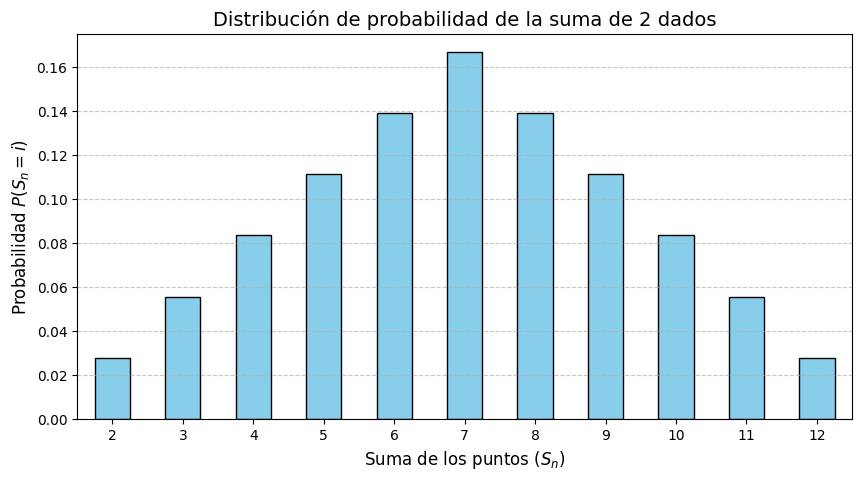

In [8]:
plt.figure(figsize=(10, 5))
Ley_Sn_float.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribución de probabilidad de la suma de 2 dados', fontsize=14)
plt.xlabel('Suma de los puntos ($S_n$)', fontsize=12)
plt.ylabel('Probabilidad $P(S_n = i)$', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

---

##### ***2-. MODELOS DE DISTRIBUCIONES DISCRETAS***

Aquí exploraremos los modelos matemáticos diseñados para fenómenos con resultados contables o finitos, donde cada valor de la variable aleatoria puede ser identificado claramente.

**Distribución Uniforme Discreta:** Describe una variable aleatoria discreta en la que todos los valores posibles tienen la misma probabilidad de ocurrir.

$$f(k; a, b) = \frac{1}{b - a + 1}$$

Donde $k$ es uno de los valores posibles de la variable aleatoria, $a$ y $b$ son los límites inferior y superior del conjunto de valores (enteros consecutivos), y $n = b−a+1$ es el número total de valores posibles, por lo que cada uno tiene probabilidad $\frac{1}{n}$

Con:

- $E[X] = \frac{a + b}{2}$

- $Var(X) = \frac{(b - a + 1)^2 - 1}{12}$

Y con una función de distribución acumulada dada por:

$$F(k; a, b) = \frac{k - a + 1}{b - a + 1}$$

 **Gráfica de su función de masa de probabilidad:**

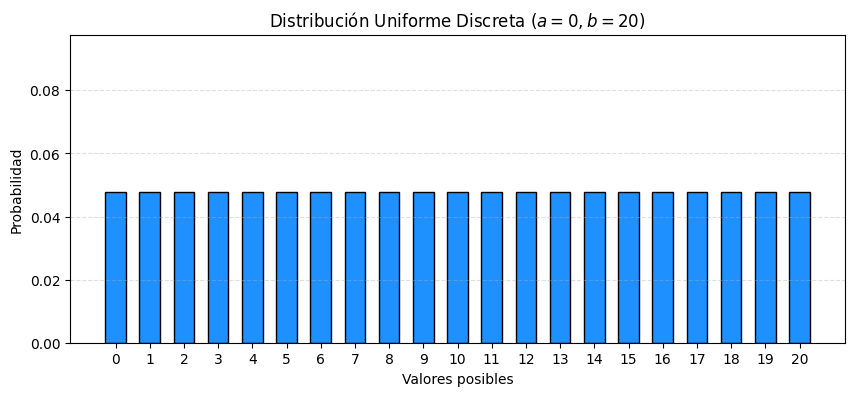

In [9]:
# @title
a = 0
b = 20
n = b - a + 1

k = np.arange(a, b + 1)
pmf_unif = np.full_like(k, 1/n, dtype=float)

plt.figure(figsize=(10, 4))
plt.bar(k, pmf_unif, width=0.6, color='dodgerblue', edgecolor='black')
plt.title(f'Distribución Uniforme Discreta ($a={a}, b={b}$)')
plt.xlabel('Valores posibles')
plt.ylabel('Probabilidad')
plt.xticks(k)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.ylim(0, (1/n) + 0.05)
plt.show()

---

**Distribución Bernoulli:** Se utiliza cuando un experimento tiene únicamente dos resultados posibles, éxito o fracaso.

$$f(k; p) = p^k (1-p)^{1-k}$$

Donde $k$ es el resultado del experimento (1 para éxito y 0 para fracaso) y $p$ es la probabilidad de éxito.

Con:

- $E[X] = p$

- $Var(X) = p(1-p)$

Y con una función de distribución acumulada dada por:

$$F(k; p) = \begin{cases} 0 & k < 0 \\ 1 - p & 0 \leq k < 1 \\ 1 & k \geq 1 \end{cases}$$

 **Gráfica de su función de masa de probabilidad:**

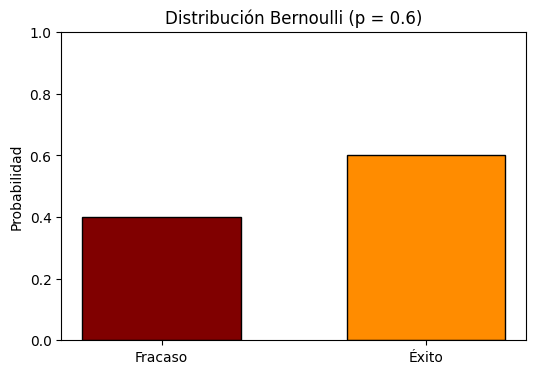

In [10]:
# @title
from scipy.stats import bernoulli

p_bernoulli = 0.6
k_bernoulli = [0, 1]
pmf_bernoulli = sps.bernoulli.pmf(k_bernoulli, p_bernoulli)

plt.figure(figsize=(6, 4))
plt.bar(['Fracaso', 'Éxito'], pmf_bernoulli, color=['maroon', 'darkorange'], edgecolor='black', width=0.6)
plt.title(f'Distribución Bernoulli (p = {p_bernoulli})')
plt.ylabel('Probabilidad')
plt.ylim(0, 1)
plt.show()

---

**Distribución Binomial:** Modela el número de éxitos en $n$ ensayos independientes de Bernoulli con probabilidad $p$.

$$f(k; n, p) = \binom{n}{k} p^k (1-p)^{n-k}$$

Donde $k$ es el número de éxitos observados, $n$ es el número total de ensayos y $p$ es la probabilidad de éxito en cada ensayo.

Con:

- $E[X] = np$

- $Var(X) = np(1-p)$

Y con una función de distribución acumulada dada por:

$$F(k; n, p) = \sum_{i=0}^{k} \binom{n}{i} p^i (1 - p)^{n-i}$$

**Nota:** No tiene forma cerrada porque la suma no se puede simplificar en una fórmula compacta para cualquier $n$. Cada valor depende de muchos términos combinatorios.

 **Gráfica de su función de masa de probabilidad:**

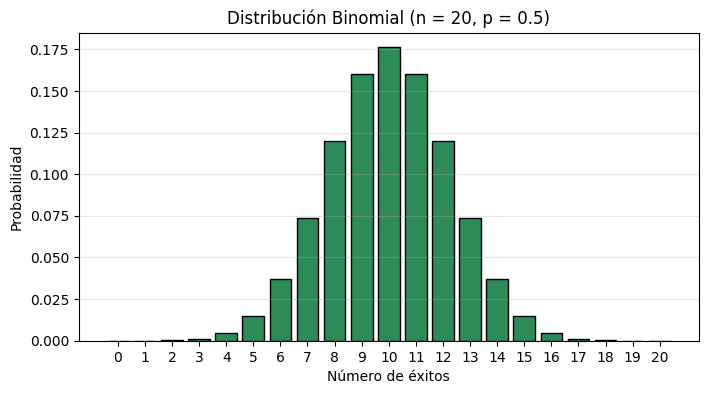

In [11]:
# @title
from scipy.stats import binom

n_bin, p_bin = 20, 0.5
k_bin = np.arange(0, n_bin + 1)
pmf_bin = sps.binom.pmf(k_bin, n_bin, p_bin)

plt.figure(figsize=(8, 4))
plt.bar(k_bin, pmf_bin, color='seagreen', edgecolor='black')
plt.title(f'Distribución Binomial (n = {n_bin}, p = {p_bin})')
plt.xlabel('Número de éxitos')
plt.ylabel('Probabilidad')
plt.xticks(k_bin)
plt.grid(axis='y', alpha=0.3)
plt.show()

---

**Distribución de Poisson:** Representa el número de eventos que ocurren en un intervalo fijo de tiempo o espacio, dado un promedio conocido de ocurrencias.

$$f(k; \lambda) = \frac{e^{-\lambda} \lambda^k}{k!}$$

Donde $k$ es el número de eventos observados y $λ$ es la tasa promedio de ocurrencia de eventos en el intervalo considerado.

Con:

- $E[X] = \lambda$

- $Var(X) = \lambda$

Y con una función de distribución acumulada dada por:

$$F(k; \lambda) = e^{-\lambda} \sum_{i=0}^{k} \frac{\lambda^i}{i!}$$

**Nota:** No tiene forma cerrada porque involucra una suma infinita o truncada con factoriales, que no se puede reducir a una expresión simple.

 **Gráfica de su función de masa de probabilidad:**

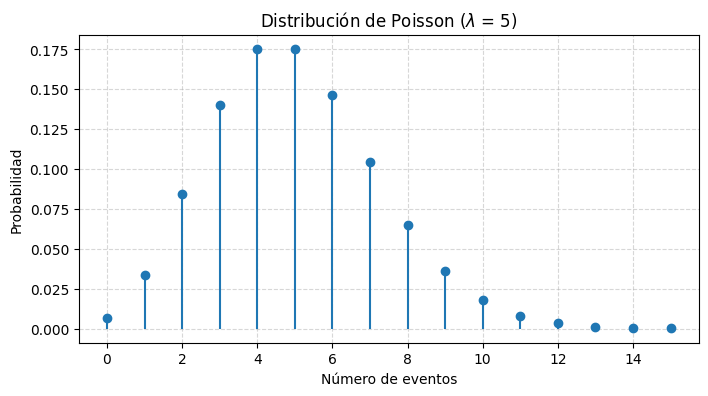

In [12]:
# @title
from scipy.stats import poisson

lam_poisson = 5
k_poisson = np.arange(0, 16)
pmf_poisson = sps.poisson.pmf(k_poisson, lam_poisson)

plt.figure(figsize=(8, 4))
plt.stem(k_poisson, pmf_poisson, linefmt='C0-', markerfmt='C0o', basefmt=" ")
plt.title(rf'Distribución de Poisson ($\lambda$ = {lam_poisson})')
plt.xlabel('Número de eventos')
plt.ylabel('Probabilidad')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---

**Distribución Geométrica:** Modela el número de ensayos necesarios para obtener el primer éxito.

$$f(k; p) = (1-p)^{k-1}p$$

Donde $k$ es el número de ensayos realizados hasta obtener el primer éxito y $p$ es la probabilidad de éxito en cada ensayo.

Con:

- $E[X] = \frac{1}{p}$

- $Var(X) = \frac{1-p}{p^2}$

Y con una función de distribución acumulada dada por:

$$F(k; p) = 1 - (1 - p)^k$$

**Nota:** Sí tiene forma cerrada porque es una serie geométrica que se puede simplificar.

 **Gráfica de su función de masa de probabilidad:**

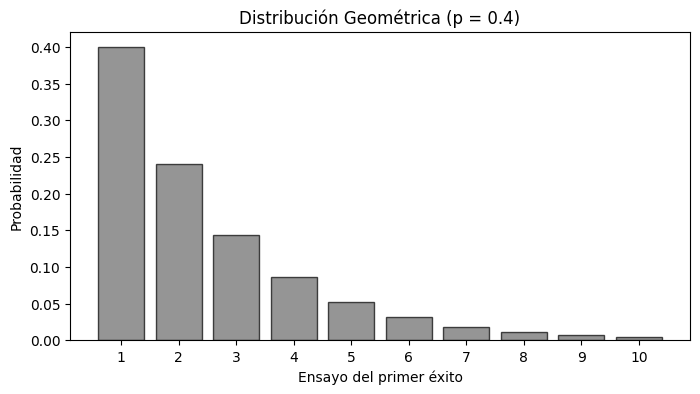

In [13]:
# @title
p_geom = 0.4
k_geom = np.arange(1, 11)
pmf_geom = sps.geom.pmf(k_geom, p_geom)

plt.figure(figsize=(8, 4))
plt.bar(k_geom, pmf_geom, color='dimgray', alpha=0.7, edgecolor='black')
plt.title(f'Distribución Geométrica (p = {p_geom})')
plt.xlabel('Ensayo del primer éxito')
plt.ylabel('Probabilidad')
plt.xticks(k_geom)
plt.show()

---

**Distribución Binomial Negativa:** Modela el número de ensayos necesarios para obtener el $r$-ésimo éxito.

$$f(k; r, p) = \binom{k-1}{r-1} (1-p)^{k-r} p^r$$

Donde $k$ es el número total de ensayos realizados, $r$ es el número de éxitos deseados y $p$ es la probabilidad de éxito en cada ensayo.

Con:

- $E[X] = \frac{r}{p}$

- $Var(X) = \frac{r(1-p)}{p^2}$

Y con una función de distribución acumulada dada por:

$$F(k; r, p) = \sum_{i=r}^{k} \binom{i-1}{r-1} p^r (1 - p)^{i-r}$$

**Nota:** No tiene forma cerrada porque combina coeficientes binomiales y potencias; no se simplifica en una sola expresión.

 **Gráfica de su función de masa de probabilidad:**

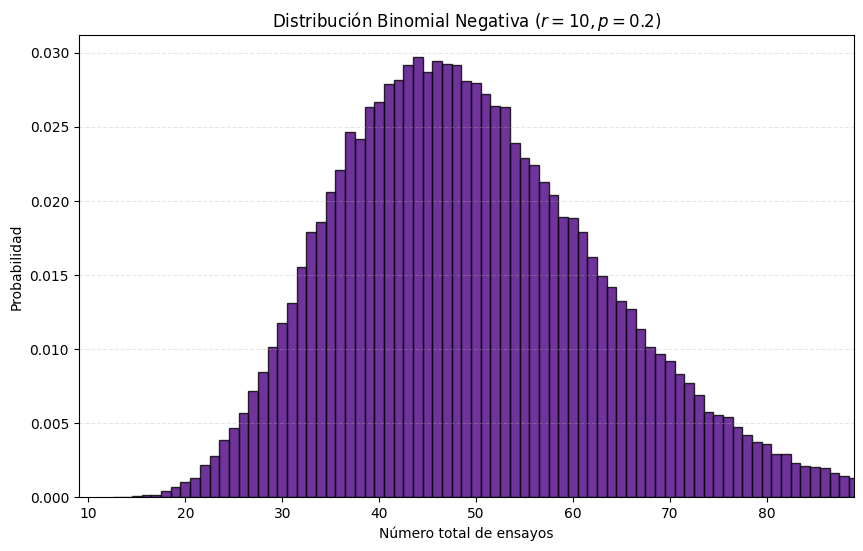

In [14]:
# @title
r = 10
p = 0.2
s = 100000

np.random.seed(3)
fracasos = sps.nbinom.rvs(r, p, size=s)
k_total_ensayos = fracasos + r

plt.figure(figsize=(10, 6))
plt.hist(
    k_total_ensayos,
    density=True,
    bins=np.arange(k_total_ensayos.min(), k_total_ensayos.max() + 1) - 0.5,
    color="indigo",
    edgecolor="black",
    alpha=0.8)

plt.xlabel('Número total de ensayos')
plt.ylabel('Probabilidad')
plt.title(f'Distribución Binomial Negativa ($r={r}, p={p}$)')
plt.xlim(r - 1, np.percentile(k_total_ensayos, 99))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

---

**Distribución Hipergeométrica:** Se utiliza en muestreos sin reemplazo de una población finita. A diferencia de la binomial, las probabilidades cambian en cada ensayo.

$$f(k; N, m, n) = \frac{\binom{m}{k} \binom{N-m}{n-k}}{\binom{N}{n}}$$

Donde $N$ es el tamaño total de la población, $m$ es el número de elementos con la característica de interés (éxitos), $n$ es el tamaño de la muestra y $k$ es el número de éxitos obtenidos en la muestra.

Con:

- $E[X] = n \frac{m}{N}$

- $Var(X) = n \frac{m}{N} (1 - \frac{m}{N}) \frac{N-n}{N-1}$

Y con una función de distribución acumulada dada por:

$$F(k; N, m, n) = \sum_{i=0}^{k} \frac{\binom{m}{i} \binom{N-m}{n-i}}{\binom{N}{n}}$$

**Nota:** No tiene forma cerrada porque depende de varias combinaciones simultáneas (población finita), lo que impide simplificar la suma.

 **Gráfica de su función de masa de probabilidad:**

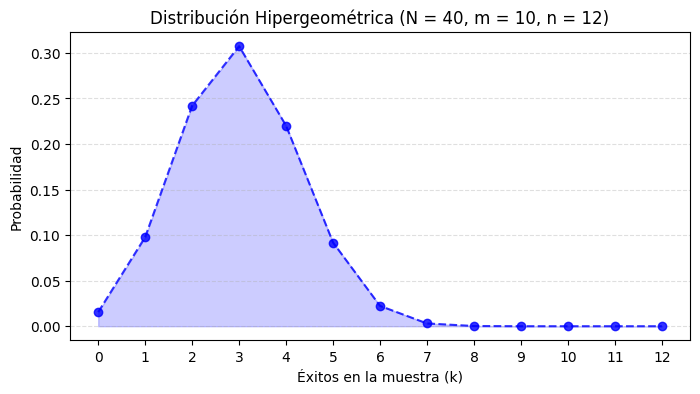

In [15]:
# @title
N_total = 40
m_exitos = 10
n_muestra = 12

k_values = np.arange(0, n_muestra + 1)
pmf_values = sps.hypergeom.pmf(k_values, N_total, m_exitos, n_muestra)

plt.figure(figsize=(8, 4))
plt.plot(k_values, pmf_values, 'bo--', alpha=0.8)
plt.fill_between(k_values, pmf_values, alpha=0.2, color='blue')
plt.title(f'Distribución Hipergeométrica (N = {N_total}, m = {m_exitos}, n = {n_muestra})')
plt.xlabel('Éxitos en la muestra (k)')
plt.ylabel('Probabilidad')
plt.xticks(k_values)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

**En conclusión:** Todas las distribuciones (discretas y continuas) tienen función de distribución acumulada; sin embargo, no todas cuentan con una expresión analítica cerrada, por lo que en algunos casos se recurre a tablas, software o aproximaciones.

---

##### ***3-. MODELOS DE DISTRIBUCIONES CONTINUAS***

En este apartado se analizan las funciones de densidad que modelan variables capaces de tomar cualquier valor dentro de un intervalo, permitiendo describir procesos de medición constante.

**Distribución Uniforme Continua:** Modela variables donde todos los intervalos de la misma longitud dentro de un rango $[a, b]$ tienen la misma probabilidad.

$$f(x; a, b) = \frac{1}{b - a}, \quad a \le x \le b$$

Donde $x$ es un valor dentro del intervalo, y $a$ y $b$ son los límites inferior y superior, respectivamente.

Con:

- $E[X] = \frac{a + b}{2}$

- $\text{Var}(X)$: $\frac{(b-a)^2}{12}$

Y con una función de distribución acumulada dada por:

$$F(x; a, b) = \frac{x - a}{b - a}$$

**Nota:** Sí tiene forma cerrada porque la integral es constante.

 **Gráfica de su función de masa de probabilidad:**

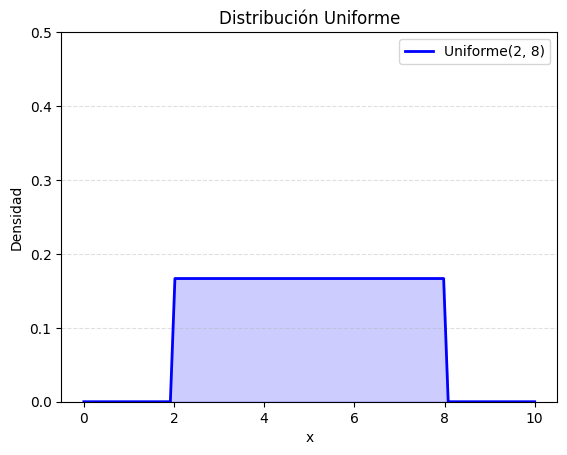

In [16]:
# @title
from scipy.stats import uniform

a, b = 2, 8
x = np.linspace(0, 10, 100)
pdf = uniform.pdf(x, loc=a, scale=b-a)

plt.plot(x, pdf, 'b-', lw=2, label=f'Uniforme({a}, {b})')
plt.fill_between(x, pdf, color='blue', alpha=0.2)
plt.ylim(0, 0.5)
plt.title('Distribución Uniforme')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend()
plt.show()

---

**Distribución Exponencial:** Se utiliza para modelar el tiempo transcurrido entre eventos o la "distancia" hasta que ocurre un suceso.

$$f(x; \lambda) = \lambda e^{-\lambda x}, \quad x > 0$$

Donde $x$ es el tiempo de espera hasta la ocurrencia del evento y $λ$ es la tasa promedio de ocurrencia de eventos.

Con:

- $E[X]$: $\frac{1}{\lambda}$

- $Var(X) = \frac{1}{\lambda^2}$

**Nota:** Posee la propiedad de pérdida de memoria, lo que significa que la probabilidad de que ocurra un evento en el futuro no depende del tiempo ya transcurrido.

Y con una función de distribución acumulada dada por:

$$F(x; \lambda) = 1 - e^{-\lambda x}$$

**Nota:** Sí tiene forma cerrada porque la integral de una exponencial es otra exponencial.

 **Gráfica de su función de masa de probabilidad:**

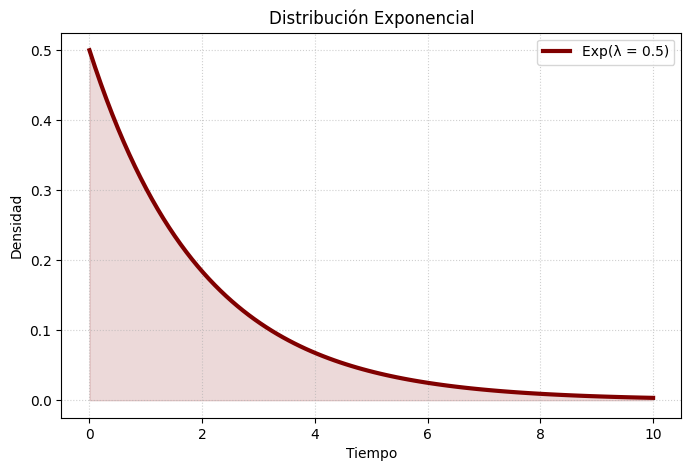

In [17]:
# @title
from scipy.stats import expon

lam = 0.5
x = np.linspace(0, 10, 100)
pdf = expon.pdf(x, scale=1/lam)

plt.figure(figsize=(8, 5))
plt.plot(x, pdf, color='maroon', lw=3, label=f'Exp(λ = {lam})')
plt.fill_between(x, pdf, color='maroon', alpha=0.15)
plt.title('Distribución Exponencial', fontsize=12)
plt.xlabel('Tiempo')
plt.ylabel('Densidad')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

---

**Distribución Normal (Gaussiana):** Es la distribución más importante en estadística debido al Teorema del Límite Central. Se caracteriza por su forma de campana simétrica.

$$f(x; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}, \quad x \in (-\infty, \infty)$$

Donde $x$ es una variable aleatoria continua definida en todo $R$, con distribución simétrica respecto a $\mu$, y cuya dispersión está determinada por $\sigma^2$.

Con:

- $E[X] = μ$

- $Var(X) = \sigma^2$

Y con una función de distribución acumulada dada por:

$$F(x; \mu, \sigma^2) = \Phi\left(\frac{x - \mu}{\sigma}\right)$$

**Nota:** No tiene forma cerrada porque la integral de $e^{-x^2}$ no se puede expresar con funciones elementales (polinomios, exponenciales, etc.).

 **Gráfica de su función de masa de probabilidad:**

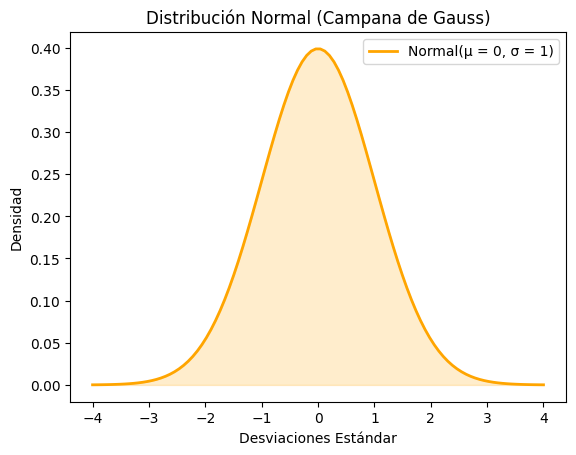

In [18]:
# @title
from scipy.stats import norm

mu, sigma = 0, 1
x = np.linspace(-4, 4, 100)
pdf = norm.pdf(x, mu, sigma)

plt.plot(x, pdf, 'orange', lw=2, label=f'Normal(μ = {mu}, σ = {sigma})')
plt.fill_between(x, pdf, color='orange', alpha=0.2)
plt.title('Distribución Normal (Campana de Gauss)')
plt.xlabel('Desviaciones Estándar')
plt.ylabel('Densidad')
plt.legend()
plt.show()

---

**Distribución Gamma:** Generalización de la distribución exponencial, útil para modelar tiempos de espera hasta el $n$-ésimo evento.

$$f(x; \alpha, \lambda) = \frac{\lambda^\alpha x^{\alpha-1} e^{-\lambda x}}{\Gamma(\alpha)}, \quad x > 0$$

Donde $x$ es la variable aleatoria continua, $\alpha$ es el parámetro de forma (número de eventos) y $λ$ es la tasa de ocurrencia.

Con:

- $E[X]$: $\frac{\alpha}{\lambda}$

- $\text{Var}(X)$: $\frac{\alpha}{\lambda^2}$

Y con una función de distribución acumulada dada por:

$$F(x; \alpha, \lambda) = \frac{\gamma(\alpha, \lambda x)}{\Gamma(\alpha)}$$

**Nota:** No tiene forma simple porque la integral involucra la función gamma incompleta, que es más compleja y no elemental.

 **Gráfica de su función de masa de probabilidad:**

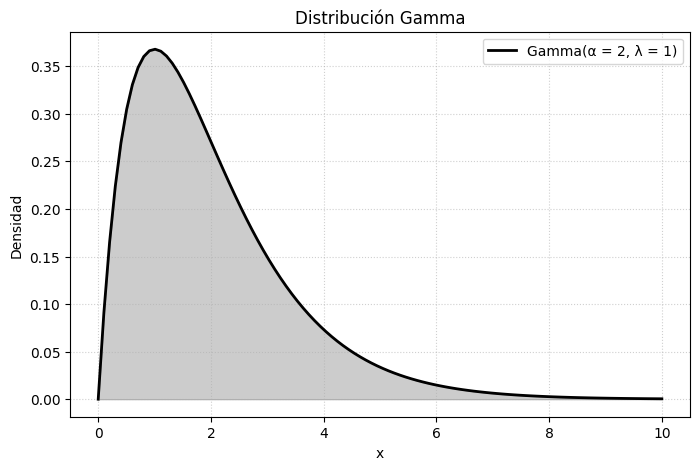

In [19]:
# @title
from scipy.stats import gamma

alpha, lam = 2, 1
x = np.linspace(0, 10, 100)
pdf = gamma.pdf(x, alpha, scale=1/lam)

plt.figure(figsize=(8, 5))
plt.plot(x, pdf, 'black', lw=2, label=f'Gamma(α = {alpha}, λ = {lam})')
plt.fill_between(x, pdf, color='black', alpha=0.2)
plt.title('Distribución Gamma')
plt.xlabel('x')
plt.ylabel('Densidad')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

---

**Distribución Beta:** Utilizada para modelar variables que representan proporciones o porcentajes en el intervalo $[0, 1]$.

$$f(x; \alpha, \beta) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha, \beta)}, \quad 0 \le x \le 1$$

Donde $x$ es la variable aleatoria, y $α$ y $β$ son parámetros de forma que determinan la forma de la distribución.

Con:

- $E[X]$: $\frac{\alpha}{\alpha + \beta}$

- $\text{Var}(X)$: $\frac{\alpha \beta}{(\alpha + \beta)^2 (\alpha + \beta + 1)}$

Y con una función de distribución acumulada dada por:

$$F(x; \alpha, \beta) = I_x(\alpha, \beta)$$

**Nota:** No tiene forma simple porque la integral genera la función beta incompleta, que tampoco es elemental.

 **Gráfica de su función de masa de probabilidad:**

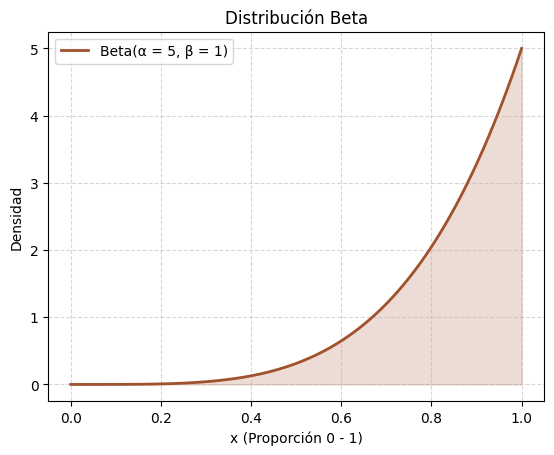

In [20]:
# @title
from scipy.stats import beta

a_param, b_param = 5, 1
x = np.linspace(0, 1, 100)
pdf = beta.pdf(x, a_param, b_param)

plt.plot(x, pdf, 'sienna', lw=2, label=f'Beta(α = {a_param}, β = {b_param})')
plt.fill_between(x, pdf, color='sienna', alpha=0.2)
plt.title('Distribución Beta')
plt.xlabel('x (Proporción 0 - 1)')
plt.ylabel('Densidad')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

**En conclusión:** Todas las distribuciones (discretas y continuas) tienen función de distribución acumulada; sin embargo, no todas cuentan con una expresión analítica cerrada, por lo que en algunos casos se recurre a tablas, software o aproximaciones.

---

##### ***4-. FUNCIONES GENERADORAS DE MOMENTOS Y FUNCIONES CARACTERÍSTICAS***

Las variables aleatorias pueden describirse mediante distintas funciones como la función de masa o densidad y la función de distribución acumulada. Sin embargo, también existen otras herramientas más avanzadas, como la función generadora de momentos y la función característica, que permiten analizar completamente una distribución.

- **Función generadora de momentos:** Se utiliza principalmente para obtener los momentos de la distribución (como la media y la varianza) a través de derivadas.

$$M_X(t) = E[e^{tX}]$$

- **Función característica:** Cumple un papel más general, ya que siempre existe y describe completamente la distribución, siendo especialmente útil en teoría de probabilidad.

$$\phi_X(t) = E[e^{itX}]$$

**TABLA RESUMEN**

A continuación, se presenta una tabla comparativa que reúne las expresiones estándar de las funciones previamente mencionadas para las distribuciones más utilizadas. Este compendio funciona como una referencia rápida que permite identificar una variable aleatoria a partir de su forma funcional, así como calcular sus momentos sin necesidad de recurrir directamente a su definición integral.

| Distribución | Función Generadora de Momentos $M_X(t)$ | Función Característica $\phi_X(t)$ |
| :--- | :--- | :--- |
| **Bernoulli** | $(1-p) + pe^t$ | $(1-p) + pe^{it}$ |
| **Uniforme Discreta** | $\frac{e^{at}-e^{(b+1)t}}{(b-a+1)(1-e^t)}$ | $\frac{e^{iat}-e^{i(b+1)t}}{(b-a+1)(1-e^{it})}$ |
| **Binomial** | $(1-p+pe^t)^n$ | $(1-p+pe^{it})^n$ |
| **Poisson** | $e^{\lambda(e^t-1)}$ | $e^{\lambda(e^{it}-1)}$ |
| **Geométrica** | $\frac{pe^t}{1-(1-p)e^t}$ | $\frac{pe^{it}}{1-(1-p)e^{it}}$ |
| **Binomial Negativa** | $\left(\frac{p}{1-(1-p)e^t}\right)^r$ | $\left(\frac{p}{1-(1-p)e^{it}}\right)^r$ |
| **Hipergeométrica**| No tiene forma cerrada simple | Existe (no simple) |
| **Uniforme Continua** | $\frac{e^{bt}-e^{at}}{t(b-a)}$ | $\frac{e^{ibt}-e^{iat}}{it(b-a)}$ |
| **Exponencial** | $\frac{\lambda}{\lambda-t}$ | $\frac{\lambda}{\lambda-it}$ |
| **Normal** | $e^{\mu t + \frac{1}{2}\sigma^2t^2}$ | $e^{i\mu t - \frac{1}{2}\sigma^2t^2}$ |
| **Gamma** | $\left(\frac{\lambda}{\lambda-t}\right)^\alpha$ | $\left(\frac{\lambda}{\lambda-it}\right)^\alpha$ |
| **Beta** | No tiene forma cerrada simple | Existe (expresión compleja) |

##### ***5-. FUNDAMENTOS DE LA GENERACIÓN ALEATORIA***

En el contexto de la simulación computacional, uno de los problemas fundamentales consiste en reproducir el comportamiento de fenómenos aleatorios mediante algoritmos. A diferencia del azar real, los sistemas computacionales son inherentemente deterministas, por lo que la aleatoriedad debe ser construida a partir de procedimientos matemáticos bien definidos.

Por esta razón, los números que se generan en simulación no son verdaderamente aleatorios, sino $pseudoaleatorios$. Estos se obtienen a partir de relaciones de recurrencia que producen secuencias que imitan las propiedades del azar, particularmente la independencia y la distribución uniforme en el intervalo $(0,1)$.

Formalmente, se busca generar una sucesión $U_1, U_2, \dots$ tal que:

$$U_i \sim \text{Unif}(0, 1)$$

y que además cumpla propiedades esenciales como independencia estadística, largo periodo y reproducibilidad. Estas características son clave, ya que permiten repetir experimentos bajo las mismas condiciones, algo indispensable en simulación.

**GENERACIÓN DE NÚMEROS UNIFORMES**

La distribución uniforme en $(0,1)$ constituye la piedra angular de la simulación. Prácticamente cualquier otra variable aleatoria puede construirse a partir de ella mediante transformaciones adecuadas.

La razón es simple pero poderosa: si se dispone de un generador confiable de variables uniformes, entonces es posible "transportar" esa aleatoriedad hacia cualquier otra distribución.

Históricamente, la generación de números uniformes ha evolucionado desde métodos manuales y tablas precomputadas hasta algoritmos computacionales altamente eficientes. Entre estos últimos, destacan los métodos congruenciales, que siguen siendo ampliamente utilizados por su simplicidad y velocidad.

**MÉTODOS CONGRUENCIALES**

Los métodos congruenciales generan secuencias de números pseudoaleatorios mediante operaciones modulares. Su fundamento se basa en la aritmética modular, donde dos números son congruentes módulo $m$ si difieren en un múltiplo de dicho módulo.

**1-. Método congruencial multiplicativo:** Este método define la sucesión mediante la relación

$$n_{i+1} = an_i \pmod m$$

donde $n_0$ es la semilla inicial. La calidad del generador depende fuertemente de la elección de los parámetros $a$ y $m$. En particular, suele tomarse $m = 2^b$ para aprovechar la arquitectura de la máquina, y elegir $a$ de forma que garantice un periodo suficientemente largo.

Aunque este método es computacionalmente eficiente y fácil de implementar, su principal limitación radica en la sensibilidad a los parámetros: una mala elección puede producir secuencias con patrones visibles o periodos cortos.

**2-. Método congruencial mixto:** Para mejorar las propiedades del generador, se introduce una constante adicional

$$n_{i+1} = (an_i + c) \pmod m$$

Este término adicional permite alcanzar periodos máximos (del orden de $m$) bajo condiciones adecuadas sobre los parámetros. En consecuencia, el método mixto suele ofrecer mejores propiedades estadísticas y una distribución más uniforme de los valores generados.

En la práctica, este método es más robusto que el multiplicativo, aunque ligeramente más complejo.

**GENERACIÓN DE VARIABLES NO UNIFORMES**

Una vez que se dispone de una fuente confiable de números uniformes, el siguiente paso consiste en generar variables con distribuciones específicas. Esto se logra mediante transformaciones matemáticas que “reconfiguran” la distribución uniforme.

El método más importante en este contexto es el de la transformada inversa.

**3-. Método de la transformada inversa:** Sea $X$ una variable aleatoria con función de distribución acumulada $F(x)$.

Si $U \sim \text{Unif}(0, 1)$, entonces:$$X = F^{-1}(U)$$

tiene la misma distribución que $X$.

Este resultado es fundamental porque permite convertir números uniformes en variables con cualquier distribución conocida, siempre que sea posible calcular o aproximar la inversa de su función de distribución.

**EJEMPLOS DE GENERACIÓN DE DISTRIBUCIONES**

Uno de los casos más simples es la distribución Bernoulli, donde el procedimiento consiste en comparar un número uniforme con la probabilidad de éxito. Este enfoque refleja directamente la interpretación probabilística de la distribución.

En el caso de la distribución exponencial, el proceso requiere despejar la variable a partir de su función de distribución acumulada, lo que conduce a la transformación:

$$X = -\frac{\ln(U)}{\lambda}$$

Este resultado es particularmente importante en simulación de tiempos de espera, como en sistemas de colas o procesos de llegada.

Por otro lado, la distribución uniforme en un intervalo $[a, b]$ se obtiene mediante una transformación lineal:

$$X = a + (b - a)U$$

lo cual ilustra claramente cómo una simple operación sobre una variable uniforme permite generar nuevas distribuciones.

Incluso distribuciones más complejas, como la de Cauchy, pueden generarse mediante transformaciones trigonométricas, lo que demuestra la versatilidad del enfoque.

----

##### ***6-. LEY DE LOS GRANDES NÚMEROS***

El método de Monte Carlo surge como una alternativa cuando un problema no puede resolverse fácilmente de forma analítica. En lugar de buscar una solución exacta, se aproxima mediante simulaciones aleatorias y el análisis del comportamiento promedio de los resultados.

Por ejemplo, para calcular el área de una figura irregular, en lugar de resolver una integral complicada, se pueden generar puntos aleatorios y estimar qué proporción cae dentro de la figura.

Este enfoque permite resolver problemas deterministas mediante aleatoriedad controlada, y se apoya en tres pilares fundamentales:

**1-. LEY DE LOS GRANDES NÚMEROS**

Es uno de los pilares fundamentales de la probabilidad y la estadística. En términos sencillos, establece que si repites un experimento aleatorio un gran número de veces, el promedio de los resultados obtenidos se aproximará cada vez más al valor esperado o media teórica del experimento.

A medida que el número de ensayos aumenta, el impacto del azar se "suaviza", permitiendo que la estabilidad surja del caos aparente.

Imagina que lanzas una moneda equilibrada. La probabilidad teórica de obtener "cara" es de $0.5$ (es decir, 50%).

- Si la lanzas 10 veces, podrías obtener 7 caras y 3 cruces (un 70% de caras). Aquí, el azar tiene mucho peso.

- Si la lanzas 1,000 veces, es mucho más probable que el porcentaje de caras esté muy cerca del 50% (por ejemplo, 498 caras).

- Si la lanzas 1,000,000 de veces, la diferencia entre el resultado real y la probabilidad teórica será prácticamente despreciable.

**LOS 2 TIPOS DE LEYES**

Aunque solemos hablar de "la ley" en singular, existen dos variantes matemáticas:

- **Ley débil -** Sugiere que, para una muestra muy grande, la probabilidad de que el promedio observado se aleje del valor teórico es casi cero.

- **Ley fuerte -** Afirma que el promedio de la muestra converge casi seguramente al valor esperado a medida que el número de ensayos tiende al infinito.

Matemáticamente, si tenemos variables aleatorias independientes e idénticamente distribuidas ($X_1, X_2, \dots, X_n$) con una media $\mu$, la ley se expresa como:

$$\bar{X}_n \to \mu \quad \text{cuando} \quad n \to \infty$$


**SIMULACIÓN DE LA LGN**

Simularemos los lanzamientos de un dado de 6 caras y analizaremos cómo se comporta la media de los resultados. En este caso, los valores posibles son $\Omega = \{1, 2, 3, 4, 5, 6\}$, y como todos tienen la misma probabilidad, la media teórica está dada por $E[X] = 3.5$

Por lo que, primero, fijamos una semilla para asegurar que los resultados sean reproducibles. Luego, generamos 10,000 lanzamientos del dado utilizando números enteros entre 1 y 6.

In [21]:
np.random.seed(42)
lanzamientos = np.random.randint(1, 7, 10000)

A continuación, calculamos la media acumulada, es decir, el promedio de los resultados conforme se van realizando más lanzamientos. Esto nos permite observar cómo la media se va estabilizando.

In [22]:
media_acumulada = np.cumsum(lanzamientos) / np.arange(1, 10001)

Después, organizamos los resultados para facilitar su visualización:

In [23]:
df = pd.DataFrame({
    'Lanzamiento': np.arange(1, 10001),
    'Media acumulada': media_acumulada})

Y finalmente, graficamos la evolución de la media muestral junto con la media teórica:

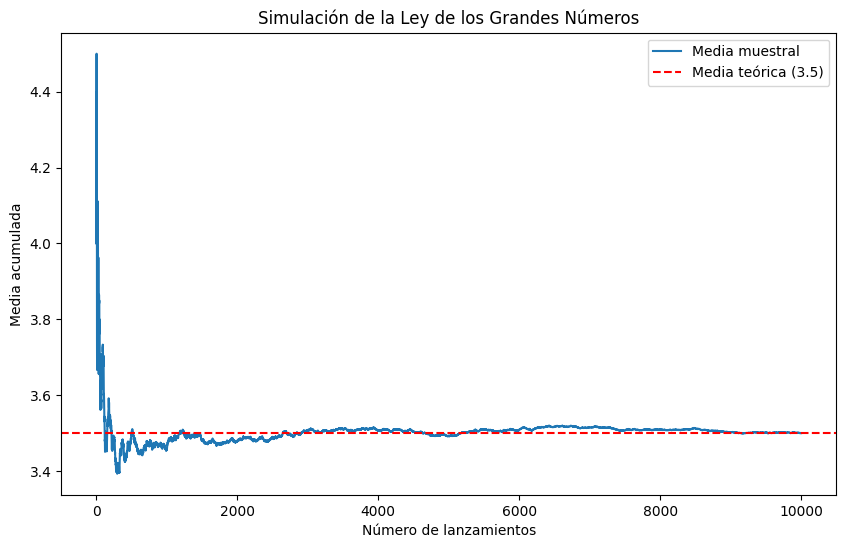

In [24]:
plt.figure(figsize=(10,6))
plt.plot(df['Lanzamiento'], df['Media acumulada'], label='Media muestral')
plt.axhline(3.5, color='red', linestyle='--', label='Media teórica (3.5)')
plt.xlabel('Número de lanzamientos')
plt.ylabel('Media acumulada')
plt.title('Simulación de la Ley de los Grandes Números')
plt.legend()
plt.show()

---

**2-. TEOREMA CENTRAL DEL LÍMITE**

Es uno de los resultados más potentes de la estadística. Indica que, independientemente de la distribución original de los datos, la distribución del promedio de las muestras tenderá a ser una distribución normal a medida que el tamaño de la muestra aumenta. Esto permite cuantificar la incertidumbre y construir intervalos de confianza para las estimaciones.

$$\bar{X} \sim N\left(\mu, \frac{\sigma^2}{n}\right)$$


**SIMULACIÓN DE EL TCL**

A continuación, se muestra mediante una simulación cómo las medias de múltiples muestras provenientes de una distribución binomial tienden a aproximarse a una distribución normal (campana de Gauss).

In [25]:
df = pd.DataFrame()

Por ello, generamos 100 muestras de tamaño 100

In [26]:
for i in range(1, 101):
    muestra = np.random.binomial(1000, 0.6, 100)
    df[f"muestra {i}"] = muestra

Para posteriormente calcular la media de cada una de las 100 muestras.

In [27]:
df_medias = pd.DataFrame(df.mean(), columns=["Media de la muestra"])

Y de esta forma poder visualizar la distribución de las medias.

In [28]:
media_teorica = 1000 * 0.6
n_muestras = 100
tamano_muestra = 100

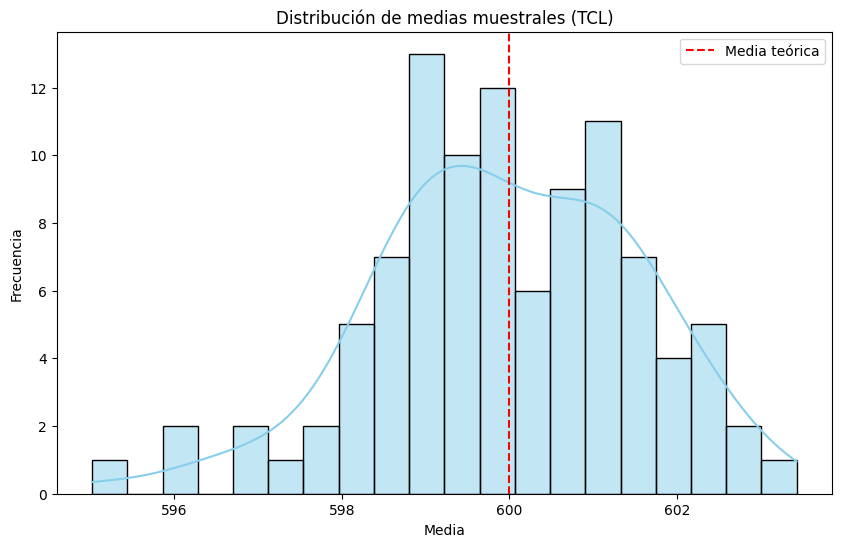

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(df_medias["Media de la muestra"], kde=True, color="skyblue", bins=20)
plt.axvline(x=media_teorica, color='red', linestyle='--', label=f"Media teórica")
plt.title(f"Distribución de medias muestrales (TCL)")
plt.xlabel("Media")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

---

**3-. INTEGRACIÓN DE MONTE CARLO**

Este método utiliza el muestreo aleatorio para calcular integrales que son difíciles de resolver analíticamente. La integral de una función $f(x)$ en un intervalo $[a, b]$ se estima promediando los valores de la función en puntos aleatorios uniformes dentro de dicho intervalo.

Matemáticamente, la aproximación se define como:

$$\int_{a}^{b} f(x) \, dx \approx \frac{b - a}{n} \sum_{i=1}^{n} f(x_i)$$

Donde cada $x_i$ es un número aleatorio generado uniformemente en el intervalo $[a, b]$.


**SIMULACIÓN DE LA INTEGRACIÓN**

Una aplicación clásica es estimar $\pi$ calculando la proporción de puntos aleatorios que caen dentro de un círculo inscrito en un cuadrado.

Primero, decidimos cuántos "dardos" vamos a lanzar. En este caso, lanzaremos 10,000. Entre más lancemos, más precisa será nuestra estimación.

In [30]:
n_puntos = 10000

Generamos dos listas de números al azar entre -1 y 1. Estos son los puntos en un plano. Imagina que el centro del cuadrado es el punto $(0,0)$.

In [31]:
x = np.random.uniform(-1, 1, n_puntos)
y = np.random.uniform(-1, 1, n_puntos)

Usamos el Teorema de Pitágoras ($a^2 + b^2 = c^2$) para saber qué tan lejos del centro está cada punto.

In [32]:
distancia_al_centro = x**2 + y**2

**Nota:** Normalmente la distancia es $\sqrt{x^2 + y^2}$, pero como el radio del círculo es $1$, y $1^2$ sigue siendo $1$, podemos ahorrarle trabajo a la computadora y no usar la raíz cuadrada.

Si la distancia al centro es menor o igual a 1, significa que el dardo cayó dentro del círculo (contamos cuántos de nuestros 10,000 dardos cumplieron esa condición).

In [33]:
dentro_del_circulo = distancia_al_centro <= 1

In [34]:
puntos_dentro = np.sum(dentro_del_circulo)

Aplicamos la proporción de "puntos dentro vs. total" y la multiplicamos por 4 para despejar el valor de $\pi$

In [35]:
estimacion_pi = 4 * (puntos_dentro / n_puntos)

Y, por último, visualizamos la figura, donde se grafican en azul los puntos que cumplen la condición de estar dentro del círculo, mientras que en rojo se muestran aquellos que quedan fuera.

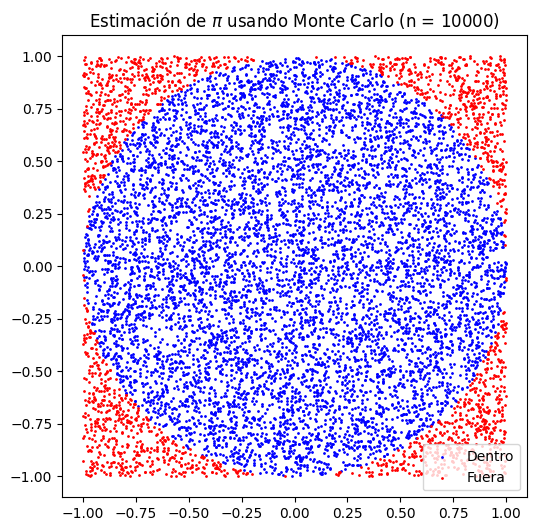

In [36]:
plt.figure(figsize=(6, 6))
plt.scatter(x[dentro_del_circulo], y[dentro_del_circulo], color='blue', s=1, label='Dentro')
plt.scatter(x[~dentro_del_circulo], y[~dentro_del_circulo], color='red', s=1, label='Fuera')
plt.title(fr"Estimación de $\pi$ usando Monte Carlo (n = 10000)")
plt.legend()
plt.show()

---

#***EJERCICIOS***

![nombre alternativo](https://materias.df.uba.ar/ft3a2014c1/files/2014/04/M-tahur-128c-vd-fully-crr-gimp-500bb.gif)

##### **PROBLEMA 1:**

Un examen de estadística consta de 20 preguntas tipo test, y se sabe, por experiencias anteriores, que un alumno tiene una probabilidad de 0.7 de contestar correctamente cada pregunta.

**En base a eso, obtiene:**

**a)** La probabilidad de que la primera pregunta que contesta bien sea la cuarta.

La fórmula a utilizar para este inciso es la de  la distribución geométrica, por lo que:

In [37]:
p = 0.7

Es la probabilidad de éxito (contestar bien)

In [38]:
q = 0.3

Es la probabilidad de fracaso (contestar mal)

In [39]:
k = 4

Es el número del intento en el que ocurre el primer éxito

In [40]:
proba = (q**(k-1)) * p

In [41]:
print(f"La probabilidad es de: {proba:.4f}")

La probabilidad es de: 0.0189


**b)** Sabiendo que para aprobar el examen es necesario contestar correctamente 10 preguntas, ¿cuál es la probabilidad de que el alumno apruebe al responder correctamente la duodécima pregunta?

Para que la duodécima pregunta corresponda al décimo acierto, en las once anteriores debieron ocurrir exactamente nueve aciertos.

In [42]:
aciertos_necesarios = 10
pregunta_final = 12

Por ende, la fórmula a utilizar para este inciso es la de la distribución binomial negativa

In [43]:
proba = math.comb(pregunta_final - 1, aciertos_necesarios - 1) * (p**10) * (q**2)

In [44]:
print(f"La probabilidad es de: {proba:.4f}")

La probabilidad es de: 0.1398


##### **PROBLEMA 2:**

Investigue sobre el problema de la caja de cerillos de Banach y explique su solución (sin simulación).

El problema plantea lo siguiente: un fumador lleva dos cajas de cerillos, una en el bolsillo izquierdo y otra en el derecho. Cada una inicia con $n$ cerillos. Cada vez que necesita uno, elige un bolsillo al azar con probabilidad $p = 1/2$. El juego termina cuando el hombre mete la mano en un bolsillo y descubre que la caja está vacía.

**El objetivo:** Calcular la probabilidad de que en ese momento exacto queden exactamente $k$ cerillos en la otra caja.

**La lógica del evento**

Para que el hombre se dé cuenta de que la caja (digamos, la izquierda) está vacía, deben ocurrir dos cosas:

- Haber elegido la caja izquierda exactamente $n + 1$ veces (las $n$ que tenían cerillos más la última vez que falló).

- Haber elegido la caja derecha exactamente $n - k$ veces.

En total, se han realizado $(n + 1) + (n - k) = 2n - k + 1$ intentos. Sin embargo, sabemos que el último intento fue obligatoriamente el que reveló la caja vacía. Por lo tanto, en los previos $2n - k$ intentos, la caja izquierda se debió elegir $n$ veces.

**La fórmula matemática**

Usamos la distribución binomial para calcular esta combinación de eventos. La probabilidad de que al descubrir una caja vacía queden $k$ en la otra es:

$$P(k) = \binom{2n - k}{n} \left( \frac{1}{2} \right)^{2n - k}$$

**Nota importante:** Como el evento puede ocurrir tanto con la caja izquierda como con la derecha, el resultado final es la suma de ambas probabilidades (que son idénticas).

**Ejemplo:** Si cada caja tiene 10 cerillos, ¿Cuál es la probabilidad de que queden 3?

In [45]:
def probabilidad_banach(n, k):
    combinaciones = math.comb(2 * n - k, n)
    probabilidad = combinaciones * (0.5**(2 * n - k))
    return probabilidad

In [46]:
n_inicial = 10
quedan = 3
resultado = probabilidad_banach(n_inicial, quedan)

In [47]:
print(f"La probabilidad de que queden {quedan} cerillos es de {resultado:.4f}")

La probabilidad de que queden 3 cerillos es de 0.1484


##### **PROBLEMA 3:**

Una compañía petrolera realiza un estudio geológico que indica que un pozo exploratorio tiene una probabilidad del 20% de encontrar petróleo.

**a)** ¿Cuál es la probabilidad de que el primer hallazgo de petróleo ocurra en el tercer pozo perforado?

La fórmula a utilizar para este inciso es la de la distribución geométrica, por lo que:

In [48]:
p_pozo = 0.2

Es el 20% de tener éxito

In [49]:
q_pozo = 0.8

Es el 80% de fallo

In [50]:
proba = (q_pozo**2) * p_pozo

In [51]:
print(f"La probabilidad es de: {proba:.3f}")

La probabilidad es de: 0.128


**b)** ¿Cuál es la probabilidad de que el tercer pozo se produzca en el séptimo pozo perforado?

Esto significa que en los primeros 6 hubo 2 éxitos, y el 7mo fue el tercero. Por ende, la fórmula a utilizar para este inciso es la de la distribución binomial negativa

In [52]:
proba = math.comb(6, 2) * (p_pozo**3) * (q_pozo**4)

In [53]:
print(f"La probabilidad es de: {proba:.4f}")

La probabilidad es de: 0.0492


**c)** ¿Cuál es la media y la varianza del número de pozos que se deben perforar para que la compañía petrolera logre establecer tres pozos productores?

Aplicamos la fórmula de la esperanza, conociendo ya el número de éxitos a obtener, siendo:

In [54]:
r = 3

In [55]:
media = r / p_pozo
print(f"Media (esperanza): {media:.0f} pozos")

Media (esperanza): 15 pozos


In [56]:
varianza = (r * q_pozo) / (p_pozo**2)
print(f"Varianza: {varianza:.0f}")

Varianza: 60


##### **PROBLEMA 4**

Una moneda no justa se lanza 6 veces, donde la probabilidad de obtener sol es de $0.3$. Sea $X$ el número de veces que cae sol. Entonces, $X$ sigue una distribución binomial con parámetros $n = 6$ y $p = 0.3$.

**Con base en esto, calcula las siguientes probabilidades:**

**a)** Probabilidad de obtener exactamente 2 soles

$P(X=2) = \binom{6}{2}(0.3)^2(0.7)^4 = 0.32$

**b)** Probabilidad de obtener exactamente 3 soles

$P(X=3) = \binom{6}{3}(0.3)^3(0.7)^3 = 0.18$

**c)** Probabilidad de obtener más de 1 pero no más de 5 soles


$\begin{align*} P(1 < X \le 5) &= P(X=2) + P(X=3) + P(X=4) + P(X=5) \\ &= 0.3241 + 0.1852 + \binom{6}{4}(0.3)^4(0.7)^2 + \binom{6}{5}(0.3)^5(0.7)^1 \\ &= 0.5093 + 0.0595 + 0.0102 = 0.57 \end{align*}$

##### **PROBLEMA 5**

Supongamos que el número de accidentes que ocurre en un punto sigue una distribución de Poisson con parámetro $\lambda = 2$.

**Con base en esto, calcula:**

**a)** ¿Cuál es la probabilidad de que en un día ocurran más de dos accidentes?

$\begin{align*}
P(X > 2) &= 1 - P(X \le 2) \\[1.2em]
&= 1 - [P(X = 0) + P(X = 1) + P(X = 2)] \\[1.2em]
&= 1 - \left[ \frac{e^{-2}2^{0}}{0!} + \frac{e^{-2}2^{1}}{1!} + \frac{e^{-2}2^{2}}{2!} \right] \\[1.2em]
&= 1 - e^{-2}[1 + 2 + 2] \\[1.2em]
&= 1 - 5e^{-2} = 0.323
\end{align*}$

**b)** ¿Cuál es la probabilidad de que en un día ocurran más de dos accidentes, sabiendo que ocurre al menos uno?

Esta es una probabilidad condicional. Primero, observamos que:

$P(X \ge 1) = 1 - P(X < 1) = 1 - P(X=0) = 1 - e^{-2}$

Entonces,

$\begin{align*}
P(X > 2 \mid X \ge 1) &= \frac{P(X > 2 \cap X \ge 1)}{P(X \ge 1)} = \frac{P(X > 2)}{P(X \ge 1)} \\[1.5em]
&= \frac{1 - P(X \le 2)}{1 - P(X < 1)} = \frac{1 - 5e^{-2}}{1 - e^{-2}} \\[1.5em]
&= \frac{0.3233}{0.8646} = 0.3739
\end{align*}$

##### **PROBLEMA 6**

Consideremos un call center donde los tiempos entre llamadas son independientes y siguen una distribución exponencial con una media de 3 minutos. Queremos calcular la probabilidad de que transcurran más de 30 minutos antes de recibir 10 llamadas.

Definimos $X$ como el tiempo total transcurrido hasta recibir la décima llamada.

Como los intervalos entre llamadas siguen una distribución exponencial, el tiempo acumulado hasta el k-ésimo evento se modela mediante una distribución Gamma.

Además, como la media de la exponencial es de 3 minutos, se tiene que:

$\lambda = 1/3$

Por lo tanto:

$X \sim \Gamma(10, \frac{1}{3})$

Ahora, buscamos la probabilidad de que el tiempo total exceda los 30 minutos:

$\displaystyle P(X > 30) = \int_{30}^{\infty} \frac{\left(\frac{1}{3}\right)^{10} x^9 e^{-\frac{x}{3}}}{9!} \, dx = 0.45793$

Esto indica que 30 minutos corresponde al valor esperado, por lo que es razonable que la probabilidad de exceder este tiempo sea cercana a 0.5.


##### **PROBLEMA 7**

Consideremos la variable aleatoria $X$ como el tiempo (en minutos) entre la llegada de dos personas a la fila de una sucursal bancaria.

Adicionalmente, el banco ha determinado que solo el 10% de las veces el tiempo que transcurre entre la llegada de una persona y otra es mayor a 2 minutos, es decir: $P(X > 2) = 0.1$

En base a esta información, se requiere determinar el valor del parámetro λ de la distribución exponencial y, posteriormente, calcular la probabilidad de que el tiempo entre llegadas sea mayor a 1 minuto, es decir, $P(X>1)$.

Por lo que, si $X \sim \text{Exp}(\lambda)$, entonces:
$\displaystyle P(X > x) = e^{-\lambda x}$

Además:

$\displaystyle P(X > 2) = 1 - P(X \leq 2) = 1 - F_X(2)$

Sustituimos:

$\displaystyle 1 - F_X(2) = 0.1 \implies F_X(2) = 0.9$


Entonces:

$\displaystyle 1 - e^{-2\lambda} = 0.9$

$\displaystyle e^{-2\lambda} = 0.1$

Aplicamos el logaritmo:

$\displaystyle -2\lambda = \ln(0.1)$

$\displaystyle \lambda = -\frac{1}{2} \ln(0.1) = 1.15$

Por lo tanto: $\displaystyle X \sim \text{Exp}(1.15)$

Ahora, calculamos la probabilidad solicitada: $P(X > 1)$

Usando la propiedad de la exponencial:

$\displaystyle P(X > x) = e^{-\lambda x}$

$\displaystyle P(X > 1) = e^{-1.15} = 0.32$

En conclusión, se determinó que $λ = 1.15$ y que la probabilidad de que el tiempo entre llegadas supere un minuto es aproximadamente $0.32$, lo que indica que intervalos mayores a un minuto no son muy frecuentes.